# 03 Portfolio Fit and Diversification Analysis

Objective: assess whether Orion, Cleanergy, or NovaTerra improves diversification relative to EDEN's current portfolio.

Current portfolio:
- ASML: €5,000
- NOVO-B: €5,000
- PVH: €7,500
- XLU: €7,500
- GLD: €10,000

Quick notes:
- The portfolio is used exactly as given in the assessment.
- A full correlation matrix is built including current holdings.
- Assess diversification through candidate correlations and before/after portfolio risk metrics.
- Fictional candidate date range is used as the main comparison window to keep all assets aligned.
- No dividends are assumed for the fictional candidates; candidate returns are based on the provided CSV price data.
- Yahoo Finance `auto_adjust=True` is used for current portfolio holdings to avoid distortions from splits and distributions.

In [1]:
# Import the necessary libraries

# Used to work with folders and file paths 
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# Detect project root by searching upward for expected folders
current_path = Path.cwd() #Identifies from what folder the notebook is being run and lists all folders until it finds the project root
candidate_roots = [current_path] + list(current_path.parents)

PROJECT_ROOT = None # Create a variable to store the project root path

"""
Create a loop to check each candidate for the presence of the expected project folders: data, notebooks, and outputs.
If a candidate contains all three folders, it is set as the project root and the loop breaks. If no candidate is found, a FileNotFoundError is raised.
"""
for path in candidate_roots:
    has_data = (path / "data").exists()
    has_notebooks = (path / "notebooks").exists()
    has_outputs = (path / "outputs").exists()
    
    if has_data and has_notebooks and has_outputs:
        PROJECT_ROOT = path
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not detect project root. Expected a folder containing data, notebooks, and outputs."
    )

# Define project folders 
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
OUTPUT_CHARTS = PROJECT_ROOT / "outputs" / "charts"
OUTPUT_TABLES = PROJECT_ROOT / "outputs" / "tables"

# Create folders if missing
DATA_RAW.mkdir(parents=True, exist_ok=True)
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
OUTPUT_CHARTS.mkdir(parents=True, exist_ok=True)
OUTPUT_TABLES.mkdir(parents=True, exist_ok=True)

# Display settings
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

# Core assumptions
TRADING_DAYS = 252
RISK_FREE_RATE = 0.03 # Assumption for Sharpe ratio calculations.

#If all folders are found, print the project root and a confirmation message
print("Project root detected:", PROJECT_ROOT)
print("Setup complete.")

Matplotlib is building the font cache; this may take a moment.


Project root detected: c:\Users\Miguel de la Cuerda\OneDrive - IE University\2nd year\EDEN fund\Technical Assessment
Setup complete.


In [ ]:
"""
Create a dictionary between the tickers that we will use and the ones we want to pull data 
from Yahoo Finance.
"""
portfolio_tickers = {
    "ASML": "ASML.AS", #Include ASML shares listed in Amsterdam 
    "NOVO-B": "NOVO-B.CO", #Include Novo Nordisk shares listed in Copenhagen
    "PVH": "PVH",
    "XLU": "XLU",
    "GLD": "GLD",
}

#Create a dictionary that assigns the corresponding positions in the portfolio to the tickers
portfolio_values = {
    "ASML": 5000,
    "NOVO-B": 5000,
    "PVH": 7500,
    "XLU": 7500,
    "GLD": 10000,
}

#Compute the total value of the portfolio 
portfolio_value_total = sum(portfolio_values.values())
#Compute the weight of each position in the portfolio 
portfolio_weights = pd.Series(portfolio_values, name="Weight") / portfolio_value_total

#Show the portfolio weights in a table format
display(portfolio_weights.to_frame())

print(f"Current portfolio value: €{portfolio_value_total:,.0f}")
print(f"New investment size: €{5000:,.0f}")
print(f"Post-investment portfolio value: €{portfolio_value_total + 5000:,.0f}")
print(f"New candidate position weight after investment: {5000 / (portfolio_value_total + 5000):.2%}")

,Weight
ASML,0.142857
NOVO-B,0.142857
PVH,0.214286
XLU,0.214286
GLD,0.285714


Current portfolio value: €35,000
New investment size: €5,000
Post-investment portfolio value: €40,000
New candidate position weight after investment: 12.50%


In [ ]:
#Create a dictionary with the file paths for the candidate data
candidate_files = {
    "Orion": DATA_RAW / "orion_eod.csv",
    "Cleanergy": DATA_RAW / "cleanergy_eod.csv",
    "NovaTerra": DATA_RAW / "novaterra_eod.csv",
}

#Create a dictionary to store the price data for each candidate
candidate_prices_dict = {}

#Create a loop to read the price data for each candidate
for candidate, file_path in candidate_files.items():
    df = pd.read_csv(file_path)
    
    # Standardize column names
    df.columns = df.columns.str.lower().str.strip()
    
    # Detect date column
    if "date" not in df.columns:
        raise ValueError(f"No 'date' column found in {file_path}. Available columns: {df.columns.tolist()}")
    
    # Detect price column
    if "adj close" in df.columns:
        price_col = "adj close"
    elif "adj_close" in df.columns:
        price_col = "adj_close"
    elif "close" in df.columns:
        price_col = "close"
    else:
        raise ValueError(f"No close price column found in {file_path}. Available columns: {df.columns.tolist()}")
    
    #Ensure that data has the correct types and is sorted by date
    df["date"] = pd.to_datetime(df["date"])
    df[price_col] = pd.to_numeric(df[price_col], errors="coerce")
    
    df = df.sort_values("date").set_index("date")
    
    candidate_prices_dict[candidate] = df[price_col]

candidate_prices = pd.DataFrame(candidate_prices_dict)

#Show the first and last observations of the candidate data 
display(candidate_prices.head())
display(candidate_prices.tail())

print("Candidate price data:")

#Indicate the starting period date
print("Start:", candidate_prices.index.min())
#Indicate the ending period date
print("End:", candidate_prices.index.max())
print("Observations:", len(candidate_prices))
print("\nMissing values:")
print(candidate_prices.isna().sum())

,Orion,Cleanergy,NovaTerra
date,,,
2012-08-31,NaN,NaN,30.157379
2012-09-03,NaN,NaN,29.589193
2012-09-04,NaN,NaN,29.973003
2012-09-05,NaN,NaN,30.550718
2012-09-06,NaN,NaN,29.520556


,Orion,Cleanergy,NovaTerra
date,,,
2026-05-18,NaN,14.280418,NaN
2026-05-19,NaN,14.090451,NaN
2026-05-20,NaN,14.261764,NaN
2026-05-21,NaN,14.411245,NaN
2026-05-22,NaN,14.899517,NaN


Candidate price data:
Start: 2012-08-31 00:00:00
End: 2026-05-22 00:00:00
Observations: 3581

Missing values:
Orion        1836
Cleanergy    1392
NovaTerra      62
dtype: int64


In [ ]:
#Indicate the starting period date
start_date = candidate_prices.index.min()
#Indicate the ending period date
end_date = candidate_prices.index.max()

#Print dates to check which period are we downloading from Yahoo Finance
print("Downloading current portfolio prices from Yahoo Finance")
print("Start date:", start_date)
print("End date:", end_date)

#Download daily adjusted price data for the current portfolio holdings 
portfolio_raw = yf.download(
    tickers=list(portfolio_tickers.values()), #Includes the tickers from the portfolio holdings
    start=start_date, #Indicate the starting period date
    end=end_date + pd.Timedelta(days=1), #Indicate the ending period date (add one day to include the end date)
    interval="1d", #Download daily data
    auto_adjust=True, #Adjust prices for corporate actions (dividends, stock splits, etc.)
    progress=False #Hide the download progress bar 
)

#Check if the downloaded data is empty and raise an error if so
if portfolio_raw.empty:
    raise ValueError("Yahoo Finance returned an empty DataFrame. Check tickers, dates, or internet connection.")

#Display the first and last observations of the downloaded portfolio data
display(portfolio_raw.head())
display(portfolio_raw.tail())

print("Downloaded portfolio raw data shape:", portfolio_raw.shape)

Start date: 2012-08-31 00:00:00
End date: 2026-05-22 00:00:00


Price           Close                                                    High                                    \
Ticker        ASML.AS         GLD  NOVO-B.CO        PVH        XLU    ASML.AS         GLD  NOVO-B.CO        PVH   
Date                                                                                                              
2012-08-31  51.311096  164.220001  69.029243  92.089554  11.499473  51.499092  164.220001  69.103229  92.668175   
2012-09-03  51.926365         NaN  69.288185        NaN        NaN  51.926365         NaN  69.769097        NaN   
2012-09-04  50.815483  164.479996  68.474350  92.550514  11.543768  51.897878  164.770004  69.473164  92.874146   
2012-09-05  51.111736  164.309998  69.325195  91.206909  11.493146  51.425051  164.389999  69.436176  92.187629   
2012-09-06  51.897877  164.889999  69.843086  92.736809  11.622850  51.897877  165.779999  70.139033  93.217367   

Price                        Low                                                    Open                         \
Ticker            XLU    ASML.AS         GLD  NOVO-B.CO        PVH        XLU    ASML.AS         GLD  NOVO-B.CO   
Date                                                                                                              
2012-08-31  11.553253  50.741417  159.559998  68.585321  91.020566  11.464675  50.952200  161.139999  69.103229   
2012-09-03        NaN  50.940816         NaN  68.955243        NaN        NaN  51.294020         NaN  69.510141   
2012-09-04  11.559585  50.701546  163.660004  68.363369  90.726375  11.464679  51.835211  164.110001  69.288198   
2012-09-05  11.556416  50.416728  163.809998  68.696313  90.598860  11.486819  50.581936  164.119995  68.807293   
2012-09-06  11.626013  50.188833  164.800003  69.362174  91.707058  11.508963  50.422403  165.160004  69.695110   

Price                                Volume                                                
Ticker            PVH        XLU    ASML.AS         GLD  NOVO-B.CO        PVH         XLU  
Date                                                                                       
2012-08-31  92.344543  11.546926  1362043.0  18024200.0  3858360.0   597400.0  12295800.0  
2012-09-03        NaN        NaN   748797.0         NaN  2606230.0        NaN         NaN  
2012-09-04  91.922854  11.480497   806049.0  12034800.0  2697500.0  1115600.0  25937400.0  
2012-09-05  92.187629  11.540598  1266849.0   8401900.0  3294270.0   787000.0   7073400.0  
2012-09-06  92.089538  11.508963  1720043.0  12961100.0  3538960.0   648300.0  11066000.0

Price             Close                                                       High                                     \
Ticker          ASML.AS         GLD   NOVO-B.CO        PVH        XLU      ASML.AS         GLD   NOVO-B.CO        PVH   
Date                                                                                                                    
2026-05-18  1264.400024  418.429993  286.000000  80.330002  43.939999  1313.199951  420.929993  295.000000  82.699997   
2026-05-19  1249.000000  411.500000  287.500000  79.419998  44.340000  1279.800049  414.470001  287.500000  80.339996   
2026-05-20  1333.000000  417.399994  288.399994  84.660004  44.509998  1336.800049  417.989990  290.649994  85.529999   
2026-05-21  1345.199951  416.989990  284.149994  86.709999  45.000000  1361.199951  418.420013  293.200012  87.099998   
2026-05-22  1409.000000  413.820007  289.000000  88.919998  45.349998  1412.599976  415.679993  291.250000  88.989998   

Price                          Low                                                       Open                          \
Ticker            XLU      ASML.AS         GLD   NOVO-B.CO        PVH        XLU      ASML.AS         GLD   NOVO-B.CO   
Date                                                                                                                    
2026-05-18  44.209999  1259.400024  416.059998  284.350006  79.809998  43.529999  1284.800049  419.820007  295.000000   
2026-05-19  44.410000  1243.199951  409.880005  278.549988  78.349998  43.619999  1254.000000  412.450012  283.100006   
2026-05-20  44.860001  1269.199951  410.079987  282.000000  78.500000  44.410000  1274.000000  412.140015  282.000000   
2026-05-21  45.009998  1318.800049  411.950012  282.399994  83.139999  44.439999  1321.199951  413.140015  289.950012   
2026-05-22  45.439999  1369.599976  412.000000  282.000000  86.430000  44.919998  1375.000000  415.170013  284.549988   

Price                               Volume                                              
Ticker            PVH        XLU   ASML.AS        GLD  NOVO-B.CO       PVH         XLU  
Date                                                                                    
2026-05-18  80.660004  44.070000  534327.0  5628300.0  7161735.0  777000.0  31554300.0  
2026-05-19  79.800003  43.820000  562705.0  5419400.0  4237279.0  753600.0  22307100.0  
2026-05-20  79.720001  44.660000  722132.0  6005000.0  3709013.0  836600.0  17584800.0  
2026-05-21  84.300003  44.549999  644698.0  4679900.0  4133116.0  892100.0  18781100.0  
2026-05-22  87.000000  45.060001  680229.0  5528400.0  3959898.0  581600.0  15187100.0

Downloaded portfolio raw data shape: (3543, 25)


In [ ]:
#Extract the close price data and rename columns to match our ticker keys
if isinstance(portfolio_raw.columns, pd.MultiIndex):
    portfolio_close = portfolio_raw["Close"].copy()
else:
    portfolio_close = portfolio_raw[["Close"]].copy()

#Create a mapping to rename the columns from the Yahoo tickers back to our original ticker keys
reverse_ticker_map = {v: k for k, v in portfolio_tickers.items()}
portfolio_close = portfolio_close.rename(columns=reverse_ticker_map)

#Check if all holdings are present in the downloaded data and raise an error if any are missing
missing_columns = [col for col in portfolio_tickers.keys() if col not in portfolio_close.columns]
if missing_columns:
    raise ValueError(f"Missing expected portfolio columns after Yahoo download: {missing_columns}")

#Reorder the columns to match the order of our portfolio tickers
portfolio_close = portfolio_close[list(portfolio_tickers.keys())]

#Show the first and last observations of the cleaned portfolio close price data
display(portfolio_close.head())
display(portfolio_close.tail())

print("Portfolio price data:")
print("Start:", portfolio_close.index.min()) #Indicate the starting period date
print("End:", portfolio_close.index.max()) #Indicate the ending period date
print("Observations:", len(portfolio_close))
print("\nMissing values:")
print(portfolio_close.isna().sum())

Ticker,ASML,NOVO-B,PVH,XLU,GLD
Date,,,,,
2012-08-31,51.311096,69.029243,92.089554,11.499473,164.220001
2012-09-03,51.926365,69.288185,NaN,NaN,NaN
2012-09-04,50.815483,68.474350,92.550514,11.543768,164.479996
2012-09-05,51.111736,69.325195,91.206909,11.493146,164.309998
2012-09-06,51.897877,69.843086,92.736809,11.622850,164.889999


Ticker,ASML,NOVO-B,PVH,XLU,GLD
Date,,,,,
2026-05-18,1264.400024,286.000000,80.330002,43.939999,418.429993
2026-05-19,1249.000000,287.500000,79.419998,44.340000,411.500000
2026-05-20,1333.000000,288.399994,84.660004,44.509998,417.399994
2026-05-21,1345.199951,284.149994,86.709999,45.000000,416.989990
2026-05-22,1409.000000,289.000000,88.919998,45.349998,413.820007


Portfolio price data:
Start: 2012-08-31 00:00:00
End: 2026-05-22 00:00:00
Observations: 3543

Missing values:
Ticker
ASML       35
NOVO-B    120
PVH        93
XLU        93
GLD        93
dtype: int64


Current portfolio prices are downloaded from Yahoo Finance with `auto_adjust=True`. Therefore, the `Close` field is used as an adjusted close-equivalent series for return calculations.

In [ ]:
#Compute candidate returns and drop NaN values 
candidate_returns = candidate_prices.pct_change().dropna()
#Compute portfolio returns and drop NaN values
portfolio_returns = portfolio_close.pct_change().dropna()

"""
Combine candidate and portfolio returns into a single DataFrame, 
aligning on dates and dropping any rows with missing values
"""
all_returns = pd.concat(
    [candidate_returns, portfolio_returns],
    axis=1,
    join="inner"
).dropna()

#Show the first and last observations of the aligned returns dataset
display(all_returns.head())
display(all_returns.tail())

#Print summary information about the returns datasets and the alignment process
print("Candidate return observations:", len(candidate_returns))
print("Portfolio return observations:", len(portfolio_returns))
print("Aligned return observations:", len(all_returns))

print("\nAligned returns dataset:")
print("Start:", all_returns.index.min())
print("End:", all_returns.index.max())
print("Observations:", len(all_returns))

print("\nMissing values:")
print(all_returns.isna().sum())

#Check if more than 20% of observations were lost during alignment and print a warning if so
if len(all_returns) < 0.8 * min(len(candidate_returns), len(portfolio_returns)):
    print("\nWarning: More than 20% of observations were lost during alignment. Check trading calendars or missing values.")

,Orion,Cleanergy,NovaTerra,ASML,NOVO-B,PVH,XLU,GLD
2019-06-21,-0.023635,-0.033314,0.005726,0.001794,-0.022460,0.031295,0.003868,0.006636
2019-06-24,0.006217,0.038950,-0.025923,-0.005708,0.003003,-0.006755,0.000328,0.014851
2019-06-25,-0.014848,0.040512,0.001695,-0.001913,0.010181,-0.014466,-0.006065,0.001941
2019-06-26,0.031191,-0.021276,-0.019720,0.009360,-0.009337,0.024866,-0.021768,-0.009165
2019-06-27,0.013675,-0.059086,0.026859,0.003910,0.000598,-0.002993,0.001349,-0.000978


,Orion,Cleanergy,NovaTerra,ASML,NOVO-B,PVH,XLU,GLD
2026-02-19,-0.015590,0.031755,0.008155,-0.005302,-0.012528,0.004759,0.010963,0.002793
2026-02-20,0.020000,0.016473,-0.003126,0.014053,-0.020820,0.035883,0.004771,0.019715
2026-02-23,-0.012069,-0.026935,0.008084,-0.005097,-0.164784,-0.042261,0.007554,0.027016
2026-02-24,0.012423,-0.013035,0.000975,0.011367,-0.030827,-0.001013,0.011140,-0.013859
2026-02-25,0.010925,-0.005482,-0.000327,0.019788,-0.021547,-0.005358,0.003390,-0.002507


Candidate return observations: 1744
Portfolio return observations: 3141
Aligned return observations: 1540

Aligned returns dataset:
Start: 2019-06-21 00:00:00
End: 2026-02-25 00:00:00
Observations: 1540

Missing values:
Orion        0
Cleanergy    0
NovaTerra    0
ASML         0
NOVO-B       0
PVH          0
XLU          0
GLD          0
dtype: int64


In [ ]:
#Export the aligned returns dataset to a CSV file for use in subsequent analysis
all_returns.to_csv(DATA_PROCESSED / "03_aligned_candidate_portfolio_daily_returns.csv")

#Show the path to which the aligned returns dataset was saved
print("Saved aligned returns to:")
print(DATA_PROCESSED / "03_aligned_candidate_portfolio_daily_returns.csv")

Saved aligned returns to:
c:\Users\Usuario\OneDrive - IE University\2nd year\EDEN fund\Technical Assessment\data\processed\03_aligned_candidate_portfolio_daily_returns.csv


In [ ]:
#Dfine the columns we expect to see in the aligned returns dataset
expected_columns = [
    "Orion",
    "Cleanergy",
    "NovaTerra",
    "ASML",
    "NOVO-B",
    "PVH",
    "XLU",
    "GLD",
]

print("Columns in all_returns:")
print(all_returns.columns.tolist())

#Check for missing expected columns and unexpected columns in the aligned returns dataset
missing_expected = [col for col in expected_columns if col not in all_returns.columns]
unexpected_columns = [col for col in all_returns.columns if col not in expected_columns]

#Indicate if any expected columns are missing and raise an error if so
if missing_expected:
    raise ValueError(f"Missing expected columns: {missing_expected}")

#Indicate if any unexpected columns are found and print them if so
if unexpected_columns:
    print(f"Unexpected columns found: {unexpected_columns}")

#Print summary information about the aligned returns dataset
print("\nDate range:")
print("Start:", all_returns.index.min())
print("End:", all_returns.index.max())
print("Observations:", len(all_returns))

print("\nMissing values:")
print(all_returns.isna().sum())

display(all_returns.describe().T)

Columns in all_returns:
['Orion', 'Cleanergy', 'NovaTerra', 'ASML', 'NOVO-B', 'PVH', 'XLU', 'GLD']

Date range:
Start: 2019-06-21 00:00:00
End: 2026-02-25 00:00:00
Observations: 1540

Missing values:
Orion        0
Cleanergy    0
NovaTerra    0
ASML         0
NOVO-B       0
PVH          0
XLU          0
GLD          0
dtype: int64


,count,mean,std,min,25%,50%,75%,max
Orion,1540.0,0.002243,0.036595,-0.284873,-0.017444,0.003020,0.023597,0.259175
Cleanergy,1540.0,0.000471,0.029155,-0.071050,-0.020083,-0.000549,0.021941,0.073783
NovaTerra,1540.0,0.000692,0.019889,-0.058373,-0.012471,0.000903,0.014397,0.063831
ASML,1540.0,0.001357,0.023813,-0.156439,-0.011468,0.001685,0.014062,0.124122
NOVO-B,1540.0,0.000115,0.022469,-0.231076,-0.010314,0.000111,0.011288,0.172622
PVH,1540.0,0.000414,0.034119,-0.218612,-0.016771,-0.000483,0.016883,0.281381
XLU,1540.0,0.000405,0.013715,-0.113577,-0.006297,0.000940,0.007165,0.127934
GLD,1540.0,0.000747,0.010788,-0.102742,-0.004721,0.000818,0.006221,0.063587


In [ ]:
#Calculate the correlation matrix for the aligned returns dataset
correlation_matrix = all_returns.corr()

#Show the correlation matrix rounded to 3 decimal places 
display(correlation_matrix.round(3))

# Full precision export for analysis
correlation_matrix.to_csv(
    OUTPUT_TABLES / "03_full_correlation_matrix.csv"
)

# Rounded export for meeting/slides
correlation_matrix.round(3).to_csv(
    OUTPUT_TABLES / "03_full_correlation_matrix_rounded.csv"
)

#Indicate that the correlation matrix has been saved
print("Saved full correlation matrix.")

,Orion,Cleanergy,NovaTerra,ASML,NOVO-B,PVH,XLU,GLD
Orion,1.000,-0.025,0.065,0.536,0.106,0.487,0.364,0.146
Cleanergy,-0.025,1.000,0.020,-0.022,0.005,-0.008,-0.030,-0.005
NovaTerra,0.065,0.020,1.000,0.038,0.051,0.087,0.031,0.019
ASML,0.536,-0.022,0.038,1.000,0.230,0.277,0.130,0.086
NOVO-B,0.106,0.005,0.051,0.230,1.000,-0.008,0.072,0.022
PVH,0.487,-0.008,0.087,0.277,-0.008,1.000,0.346,0.018
XLU,0.364,-0.030,0.031,0.130,0.072,0.346,1.000,0.218
GLD,0.146,-0.005,0.019,0.086,0.022,0.018,0.218,1.000


Saved full correlation matrix.


In [ ]:
#Define the candidate stocks that are being evaluated for the new position
candidates = ["Orion", "Cleanergy", "NovaTerra"]
#Define the current portfolio holdings 
current_holdings = ["ASML", "NOVO-B", "PVH", "XLU", "GLD"]

#Create a list to store the correlation summary for each candidate
candidate_corr_summary = []

#Iterate through the candidates and compute its correlations with current holdings
for candidate in candidates:
    correlations = correlation_matrix.loc[candidate, current_holdings]
    
    candidate_corr_summary.append({
        "Candidate": candidate,
        "Average Correlation with Current Holdings": correlations.mean(),
        "Min Correlation with Current Holdings": correlations.min(),
        "Max Correlation with Current Holdings": correlations.max(),
        "Highest-Correlation Holding": correlations.idxmax(),
        "Correlation with ASML": correlations["ASML"],
        "Correlation with XLU": correlations["XLU"],
        "Correlation with GLD": correlations["GLD"],
    })

#Create a DataFrame from the candidate correlation summary list
candidate_corr_summary_df = pd.DataFrame(candidate_corr_summary)

#Show the candidate correlation summary table rounded to 3 decimal places
display(candidate_corr_summary_df.round(3))

#Export the candidate correlation summary table to CSV files (full precision and rounded)
candidate_corr_summary_df.to_csv(
    OUTPUT_TABLES / "03_candidate_correlation_summary.csv",
    index=False
)

candidate_corr_summary_df.round(3).to_csv(
    OUTPUT_TABLES / "03_candidate_correlation_summary_rounded.csv",
    index=False
)

,Candidate,Average Correlation with Current Holdings,Min Correlation with Current Holdings,Max Correlation with Current Holdings,Highest-Correlation Holding,Correlation with ASML,Correlation with XLU,Correlation with GLD
0,Orion,0.328,0.106,0.536,ASML,0.536,0.364,0.146
1,Cleanergy,-0.012,-0.030,0.005,NOVO-B,-0.022,-0.030,-0.005
2,NovaTerra,0.045,0.019,0.087,PVH,0.038,0.031,0.019


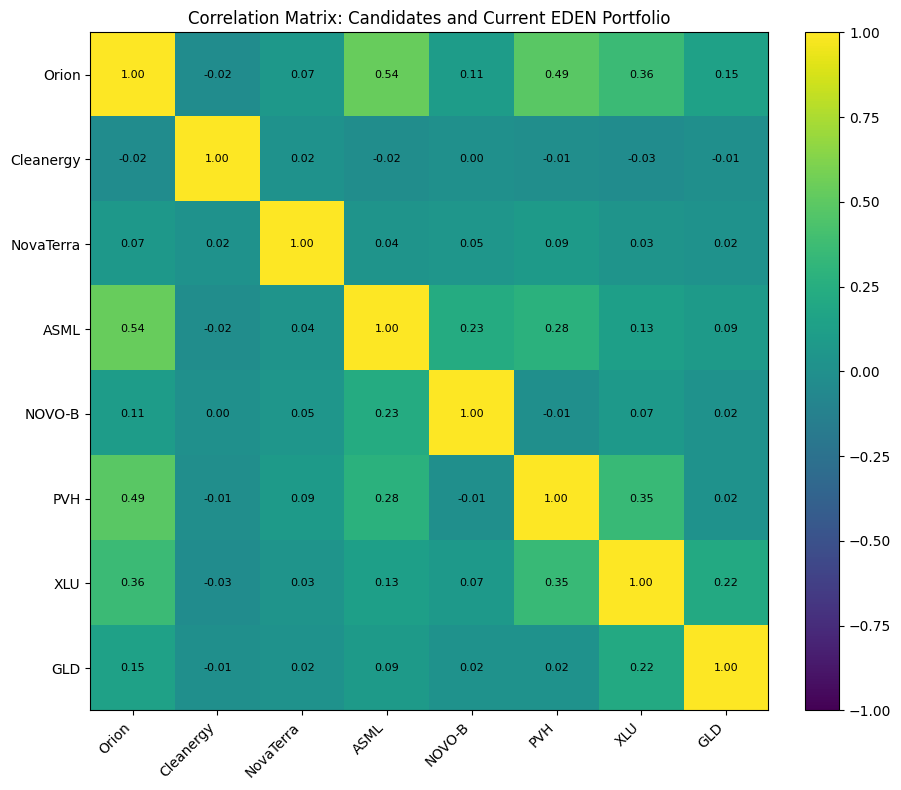

In [ ]:
#Create a heatmap to visualize the correlation matrix between candidates and current portfolio holdings
fig, ax = plt.subplots(figsize=(10, 8))

#Create a heatmap using imshow with a color scale from -1 to 1
im = ax.imshow(
    correlation_matrix,
    vmin=-1,
    vmax=1
)

#Set the ticks and labels for the heatmap axes
ax.set_xticks(np.arange(len(correlation_matrix.columns)))
ax.set_yticks(np.arange(len(correlation_matrix.index)))

"""
Set the tick labels to the column and index names of the correlation matrix, 
rotating x-axis labels for better readability
"""
ax.set_xticklabels(correlation_matrix.columns, rotation=45, ha="right")
ax.set_yticklabels(correlation_matrix.index)

#Iterate through the correlation matrix and add the correlation values as text annotations on the heatmap
for i in range(len(correlation_matrix.index)):
    for j in range(len(correlation_matrix.columns)):
        ax.text(
            j, i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

#Set the title and add a colorbar to the heatmap
ax.set_title("Correlation Matrix: Candidates and Current EDEN Portfolio")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
#Adjust layout to prevent clipping of labels and title
fig.tight_layout()

#Save the heatmap as a high-resolution PNG for use in presentations or reports
plt.savefig(
    OUTPUT_CHARTS / "03_full_correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

#Display the heatmap
plt.show()

In [ ]:
#Export the heatmap as a PDF for use in presentations or reports
plt.savefig(
    OUTPUT_CHARTS / "03_full_correlation_matrix.pdf",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

## Correlation Summary Interpretation

The correlation analysis suggests that Cleanergy provides the strongest statistical diversification benefit. Its average correlation with the current EDEN holdings is close to zero, and its correlation with XLU is also near zero. This indicates that Cleanergy is not simply replicating the existing utilities ETF exposure, despite being energy-transition / grid-infrastructure adjacent.

Orion has the weakest diversification profile among the three candidates. Its correlation with ASML is meaningfully positive, supporting the concern that Orion may duplicate EDEN's existing semiconductor / AI-capex exposure.

NovaTerra also shows low correlations with the current holdings, so it diversifies statistically. However, its strategic portfolio-gap rationale remains less direct than Cleanergy's because EDEN's visible gap is more clearly energy-transition / grid infrastructure than agritech.

This correlation evidence does not decide the recommendation by itself. The next step is to test whether adding each candidate improves or worsens total portfolio risk, volatility, Sharpe ratio, and maximum drawdown.

In [ ]:
#Define the size of the new investment
new_investment = 5000
#Compute the current total value of the portfolio and the new total value after adding the new investment
current_portfolio_value = sum(portfolio_values.values())
new_total_value = current_portfolio_value + new_investment

#Create a dictionary to store the portfolio weights for each scenario (current and candidate additions)
scenario_weights = {}

# Store current portfolio weights before new investment
scenario_weights["Current Portfolio"] = portfolio_weights.copy()

# Candidate-addition scenarios after investing €5,000
"""
Iterate through each candidate and compute the new portfolio weights 
if we were to add a €5,000 position in that candidate.
"""
for candidate in candidates:
    weights = pd.Series(dtype=float)
    
    for holding, value in portfolio_values.items():
        weights[holding] = value / new_total_value
    
    weights[candidate] = new_investment / new_total_value
    
    scenario_weights[f"Add {candidate}"] = weights

"""
Create a DataFrame from the scenario weights dictionary;
fill any missing values with 0 (for candidates not in the current portfolio)
"""
scenario_weights_df = pd.DataFrame(scenario_weights).fillna(0)

#Display the scenario weights table rounded to 4 decimal places 
display(scenario_weights_df.round(4))

#Export the scenario weights table to CSV files (full precision and rounded)
scenario_weights_df.to_csv(
    OUTPUT_TABLES / "03_scenario_weights.csv"
)

#Export the scenario weights table rounded to 4 decimal places 
scenario_weights_df.round(4).to_csv(
    OUTPUT_TABLES / "03_scenario_weights_rounded.csv"
)

,Current Portfolio,Add Orion,Add Cleanergy,Add NovaTerra
ASML,0.1429,0.1250,0.1250,0.1250
Cleanergy,0.0000,0.0000,0.1250,0.0000
GLD,0.2857,0.2500,0.2500,0.2500
NOVO-B,0.1429,0.1250,0.1250,0.1250
NovaTerra,0.0000,0.0000,0.0000,0.1250
Orion,0.0000,0.1250,0.0000,0.0000
PVH,0.2143,0.1875,0.1875,0.1875
XLU,0.2143,0.1875,0.1875,0.1875


## Portfolio Scenario Metrics

For each scenario, we calculate cumulative return, annualized return, annualized volatility, Sharpe ratio, and maximum drawdown. The Sharpe ratio uses a 3% annual risk-free-rate assumption, which should be kept consistent with the candidate quant notebook.

In [ ]:
#Define a reusable function to compute the return and risk metrics 
def calculate_return_metrics(return_series, risk_free_rate=RISK_FREE_RATE):
    return_series = return_series.dropna() #Clean the return series by dropping any missing values
    
    #Check if the return series is empty after dropping missing values and raise an error if so
    if len(return_series) == 0:
        raise ValueError("Return series is empty after dropping missing values.")
    
    cumulative_return = (1 + return_series).prod() - 1 #Compute the cumulative return over the period
    
    annualized_return = (
        (1 + cumulative_return) ** (TRADING_DAYS / len(return_series)) - 1
    ) #Compute the annualized return
    
    annualized_volatility = return_series.std() * np.sqrt(TRADING_DAYS) #Compute the annualized volatility
    
    sharpe_ratio = (
        (annualized_return - risk_free_rate) / annualized_volatility
        if annualized_volatility != 0
        else np.nan
    ) #Compute the Sharpe ratio, handling the case where volatility is zero to avoid division by zero
    
    #Compute the cumulative return curve for drawdown calculations
    cumulative_curve = (1 + return_series).cumprod() 
    #Compute the running maximum of the cumulative return curve to identify peaks
    running_max = cumulative_curve.cummax()
    #Compute the drawdown as the percentage decline from the running maximum
    drawdown = cumulative_curve / running_max - 1
    #Save the maximum drawdown (the largest negative drawdown observed) as a key risk metric
    max_drawdown = drawdown.min()
    
    #Return a dictionary with all the computed return and risk metrics for the given return series
    return {
        "Cumulative Return": cumulative_return,
        "Annualized Return": annualized_return,
        "Annualized Volatility": annualized_volatility,
        "Sharpe Ratio": sharpe_ratio,
        "Max Drawdown": max_drawdown,
    }

In [ ]:
#Create a dictionary to store the return series for each portfolio scenario
portfolio_scenarios = {}

# Compute the return series for the current portfolio
portfolio_scenarios["Current Portfolio"] = all_returns[current_holdings].dot(
    portfolio_weights[current_holdings]
)

# Compute the return series for each candidate-addition scenario
for candidate in candidates:
    scenario_name = f"Add {candidate}" #Create a scenario name 
    scenario_assets = current_holdings + [candidate] #Define the assets included in the scenario
    #Extract the weights for the assets included in the scenario from the scenario weights DataFrame
    weights = scenario_weights_df[scenario_name].loc[scenario_assets] 
    
    #Check that the weights sum to 1 for the scenario and raise an error if not
    weight_sum = weights.sum()
    if not np.isclose(weight_sum, 1.0):
        raise ValueError(f"Weights for {scenario_name} sum to {weight_sum:.6f}, not 1.0")
    
    #Compute the return series for the scenario as the weighted sum of the returns of the included assets
    portfolio_scenarios[scenario_name] = all_returns[scenario_assets].dot(weights)

#Create a DataFrame from the portfolio scenarios dictionary
portfolio_scenario_returns = pd.DataFrame(portfolio_scenarios)

#Show the portfolio scenarios return
display(portfolio_scenario_returns.head())

#Export the scenarios returns 
portfolio_scenario_returns.to_csv(
    DATA_PROCESSED / "03_portfolio_scenario_daily_returns.csv"
)

#Indicate the file path the dataframe has been exported to 
print("Saved portfolio scenario daily returns.")

,Current Portfolio,Add Orion,Add Cleanergy,Add NovaTerra
2019-06-21,0.006478,0.002714,0.001504,0.006384
2019-06-24,0.002479,0.002947,0.007038,-0.001071
2019-06-25,-0.002664,-0.004187,0.002733,-0.002119
2019-06-26,-0.001952,0.002191,-0.004367,-0.004173
2019-06-27,0.000013,0.001720,-0.007375,0.003368


Saved portfolio scenario daily returns.


In [ ]:
#Create an empty list that will store performance metrics 
scenario_metrics = []

#Iterate through the columns in the portfolio scenario returns dataframe
for scenario_name in portfolio_scenario_returns.columns:
    #Compute the main risk and return metrics for the scenario's return series
    metrics = calculate_return_metrics(portfolio_scenario_returns[scenario_name])
    #Add the scenario names to the metrics dataset
    metrics["Scenario"] = scenario_name
    scenario_metrics.append(metrics)

#Covert the scenario metrics into a dataframe
scenario_metrics_df = pd.DataFrame(scenario_metrics)

#Reorder the columns to facilitate interpretation
scenario_metrics_df = scenario_metrics_df[
    [
        "Scenario",
        "Cumulative Return",
        "Annualized Return",
        "Annualized Volatility",
        "Sharpe Ratio",
        "Max Drawdown",
    ]
]

#Show the daily metrics dataframe
display(scenario_metrics_df)

#Create a copy of the scenario metrics to format it 
scenario_metrics_display = scenario_metrics_df.copy()

#Define the variables that have to be converted to percentage format
percentage_cols = [
    "Cumulative Return",
    "Annualized Return",
    "Annualized Volatility",
    "Max Drawdown",
]

#Iterate through the established variables to convert those into percentage format (2 decimals)
for col in percentage_cols:
    scenario_metrics_display[col] = scenario_metrics_display[col].map(lambda x: f"{x:.2%}")

#Round the Sharpe ratio to 2 decimals
scenario_metrics_display["Sharpe Ratio"] = scenario_metrics_display["Sharpe Ratio"].map(lambda x: f"{x:.2f}")

#Show the formatted portfolio metrics dataframe
display(scenario_metrics_display)

#Export the portfolio metrics
scenario_metrics_df.to_csv(
    OUTPUT_TABLES / "03_before_after_portfolio_metrics.csv",
    index=False
)

#Export the formatted portfolio metrics
scenario_metrics_display.to_csv(
    OUTPUT_TABLES / "03_before_after_portfolio_metrics_formatted.csv",
    index=False
)

,Scenario,Cumulative Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown
0,Current Portfolio,1.263351,0.143011,0.186312,0.606568,-0.326991
1,Add Orion,1.995143,0.196628,0.215560,0.773001,-0.352183
2,Add Cleanergy,1.243426,0.141358,0.171926,0.647709,-0.380951
3,Add NovaTerra,1.342408,0.149450,0.171212,0.697676,-0.313707


,Scenario,Cumulative Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown
0,Current Portfolio,126.34%,14.30%,18.63%,0.61,-32.70%
1,Add Orion,199.51%,19.66%,21.56%,0.77,-35.22%
2,Add Cleanergy,124.34%,14.14%,17.19%,0.65,-38.10%
3,Add NovaTerra,134.24%,14.95%,17.12%,0.70,-31.37%


In [ ]:
#Set the scenario name as the index of the dataframe
scenario_metrics_indexed = scenario_metrics_df.set_index("Scenario")
"""
Extract the baseline metrics for the current portfolio,
all scenarios will be compared against this row
"""
current_metrics = scenario_metrics_indexed.loc["Current Portfolio"]

#Create a list to store the incremental impact of each candidate 
incremental_impact = []

#Iterate through each candidate and compare their metrics with the current portfolio
for candidate in candidates:
    scenario_name = f"Add {candidate}"
    scenario = scenario_metrics_indexed.loc[scenario_name] #Extract the metrics for the scenario
    
    #Compute the incremental change against the current portfolio
    incremental_impact.append({
        "Candidate Added": candidate,
        "Change in Annualized Return": scenario["Annualized Return"] - current_metrics["Annualized Return"],
        "Change in Annualized Volatility": scenario["Annualized Volatility"] - current_metrics["Annualized Volatility"],
        "Change in Sharpe Ratio": scenario["Sharpe Ratio"] - current_metrics["Sharpe Ratio"],
        "Change in Max Drawdown": scenario["Max Drawdown"] - current_metrics["Max Drawdown"],
    })

#Transform the dictionary containing the incremental changes into a dataframe
incremental_impact_df = pd.DataFrame(incremental_impact)

#Show the incremental changes
display(incremental_impact_df)

#Copy the incremental dataframe to format it  
incremental_impact_display = incremental_impact_df.copy()

#Indicate the variables that have percentage format 
percentage_cols = [
    "Change in Annualized Return",
    "Change in Annualized Volatility",
    "Change in Max Drawdown",
]

#Apply percentage format to the mentioned variables
for col in percentage_cols:
    incremental_impact_display[col] = incremental_impact_display[col].map(lambda x: f"{x:.2%}")

#Round the change in Sharpe ratio to 2 decimals
incremental_impact_display["Change in Sharpe Ratio"] = incremental_impact_display["Change in Sharpe Ratio"].map(lambda x: f"{x:.2f}")

#Show the formatted dataframe with the incremental changes
display(incremental_impact_display)

#Export the incremental changes dataframe
incremental_impact_df.to_csv(
    OUTPUT_TABLES / "03_candidate_incremental_portfolio_impact.csv",
    index=False
)

#Export the formatted incremental changes dataframe
incremental_impact_display.to_csv(
    OUTPUT_TABLES / "03_candidate_incremental_portfolio_impact_formatted.csv",
    index=False
)

,Candidate Added,Change in Annualized Return,Change in Annualized Volatility,Change in Sharpe Ratio,Change in Max Drawdown
0,Orion,0.053617,0.029248,0.166433,-0.025193
1,Cleanergy,-0.001653,-0.014386,0.041141,-0.053960
2,NovaTerra,0.006440,-0.015100,0.091108,0.013283


,Candidate Added,Change in Annualized Return,Change in Annualized Volatility,Change in Sharpe Ratio,Change in Max Drawdown
0,Orion,5.36%,2.92%,0.17,-2.52%
1,Cleanergy,-0.17%,-1.44%,0.04,-5.40%
2,NovaTerra,0.64%,-1.51%,0.09,1.33%


## Incremental Impact Interpretation Note

This table measures the change in portfolio metrics after adding each candidate. A positive change in annualized return or Sharpe ratio is favorable. A negative change in annualized volatility is favorable because it means lower risk. For maximum drawdown, a positive change is favorable because max drawdown is expressed as a negative number; a negative change means the drawdown became more severe.

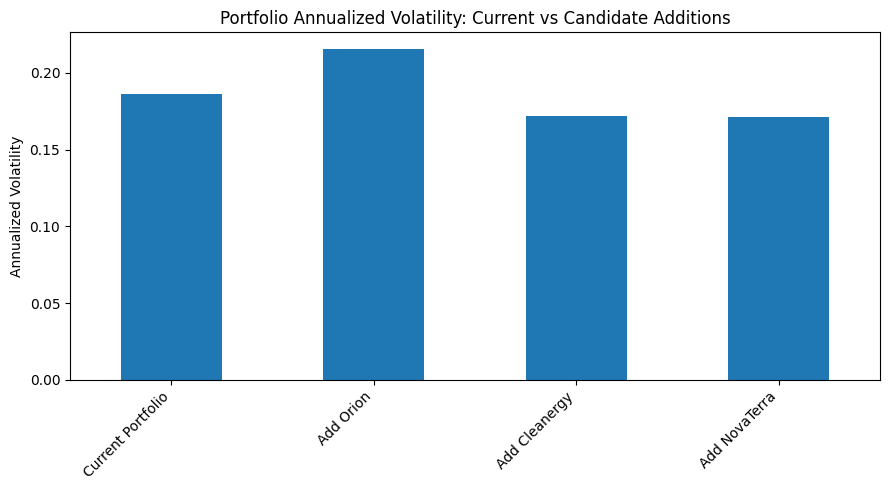

In [ ]:
#Create a barchart comparing annualised portfolio volatility across scenarios
ax = scenario_metrics_df.set_index("Scenario")["Annualized Volatility"].plot(
    kind="bar",
    figsize=(9, 5)
)

ax.set_title("Portfolio Annualized Volatility: Current vs Candidate Additions") #Set the graph title
ax.set_ylabel("Annualized Volatility") #Set the name of the y-axis
ax.set_xlabel("") #Set the name of the x-axis
plt.xticks(rotation=45, ha="right") #Rotate the name in the x-axis
plt.tight_layout()

#Export the chart as an image
plt.savefig(
    OUTPUT_CHARTS / "03_scenario_annualized_volatility.png",
    dpi=300,
    bbox_inches="tight"
)

#Show the chart
plt.show()

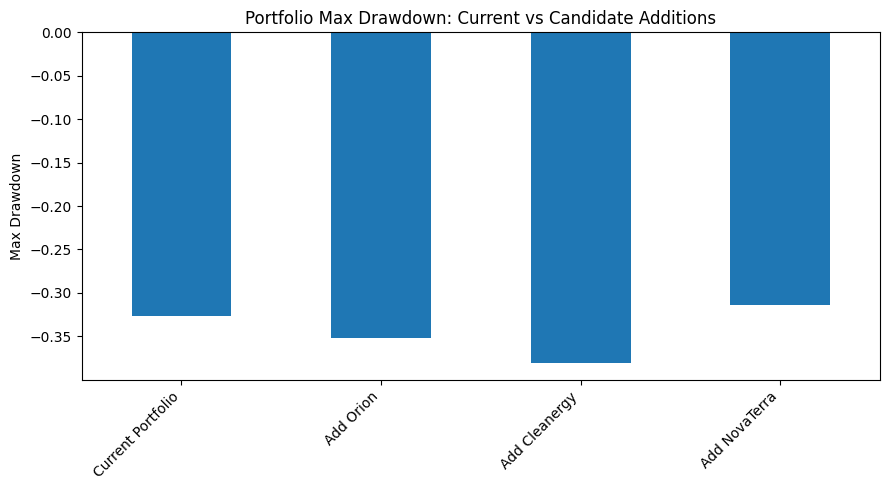

In [ ]:
#Create a barchart comparing the maximum drawdown for the scenarios
ax = scenario_metrics_df.set_index("Scenario")["Max Drawdown"].plot(
    kind="bar",
    figsize=(9, 5)
)

ax.set_title("Portfolio Max Drawdown: Current vs Candidate Additions") #Set the title of the graph
ax.set_ylabel("Max Drawdown") #Set the name of the y-axis
ax.set_xlabel("") #Set the name of the x-axis
plt.xticks(rotation=45, ha="right") #Rotate the names in the x-axis
plt.tight_layout()

#Save the chart as an image
plt.savefig(
    OUTPUT_CHARTS / "03_scenario_max_drawdown.png",
    dpi=300,
    bbox_inches="tight"
)

#Show the chart
plt.show()

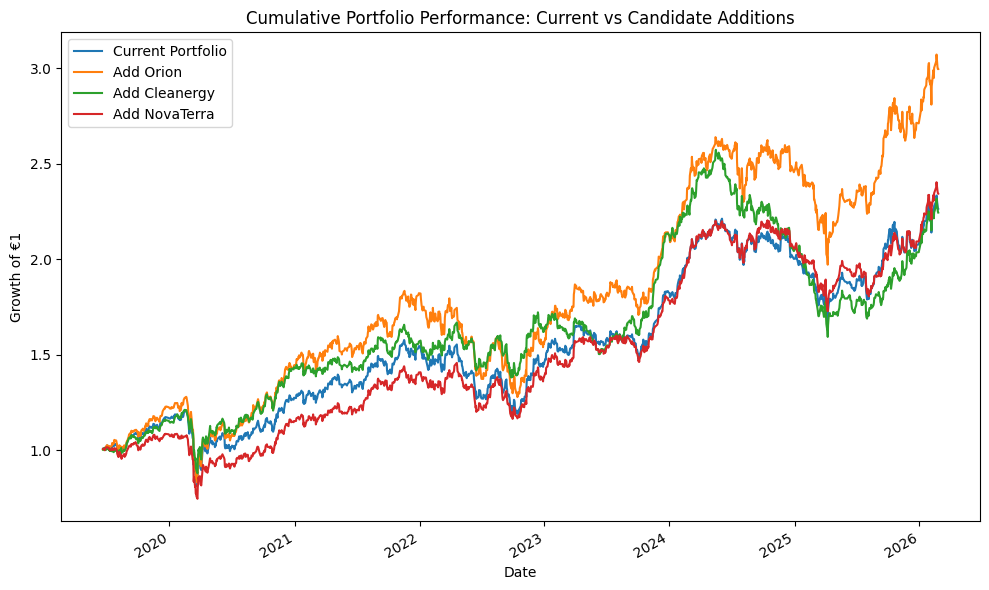

In [ ]:
#Compute the cumulative return for each scenario
cumulative_scenarios = (1 + portfolio_scenario_returns).cumprod()

#Create the area for the chart
ax = cumulative_scenarios.plot(figsize=(10, 6))

ax.set_title("Cumulative Portfolio Performance: Current vs Candidate Additions") #Set the chart title
ax.set_ylabel("Growth of €1") #Set the name of the y-axis
ax.set_xlabel("Date") #Set the name of the x-axis
plt.tight_layout()

#Export the chart as an image
plt.savefig(
    OUTPUT_CHARTS / "03_scenario_cumulative_performance.png",
    dpi=300,
    bbox_inches="tight"
)

#Show the chart
plt.show()

In [ ]:
#Export the notebook outputs
print("\nKey tables exported to:")
print(OUTPUT_TABLES / "03_full_correlation_matrix.csv")
print(OUTPUT_TABLES / "03_candidate_correlation_summary.csv")
print(OUTPUT_TABLES / "03_scenario_weights.csv")
print(OUTPUT_TABLES / "03_before_after_portfolio_metrics.csv")
print(OUTPUT_TABLES / "03_candidate_incremental_portfolio_impact.csv")

print("\nKey processed data exported to:")
print(DATA_PROCESSED / "03_aligned_candidate_portfolio_daily_returns.csv")
print(DATA_PROCESSED / "03_portfolio_scenario_daily_returns.csv")

print("\nKey charts exported to:")
print(OUTPUT_CHARTS / "03_full_correlation_matrix.png")
print(OUTPUT_CHARTS / "03_scenario_annualized_volatility.png")
print(OUTPUT_CHARTS / "03_scenario_max_drawdown.png")
print(OUTPUT_CHARTS / "03_scenario_cumulative_performance.png")

Notebook 03 completed.

Key tables exported to:
c:\Users\Usuario\OneDrive - IE University\2nd year\EDEN fund\Technical Assessment\outputs\tables\03_full_correlation_matrix.csv
c:\Users\Usuario\OneDrive - IE University\2nd year\EDEN fund\Technical Assessment\outputs\tables\03_candidate_correlation_summary.csv
c:\Users\Usuario\OneDrive - IE University\2nd year\EDEN fund\Technical Assessment\outputs\tables\03_scenario_weights.csv
c:\Users\Usuario\OneDrive - IE University\2nd year\EDEN fund\Technical Assessment\outputs\tables\03_before_after_portfolio_metrics.csv
c:\Users\Usuario\OneDrive - IE University\2nd year\EDEN fund\Technical Assessment\outputs\tables\03_candidate_incremental_portfolio_impact.csv

Key processed data exported to:
c:\Users\Usuario\OneDrive - IE University\2nd year\EDEN fund\Technical Assessment\data\processed\03_aligned_candidate_portfolio_daily_returns.csv
c:\Users\Usuario\OneDrive - IE University\2nd year\EDEN fund\Technical Assessment\data\processed\03_portfolio_sc

## Final Notebook 03 Interpretation

This notebook assesses whether the three fictional candidates improve diversification relative to EDEN's current portfolio.

The correlation evidence favors Cleanergy from a diversification perspective. Cleanergy has near-zero average correlation with the current holdings and near-zero correlation with XLU, suggesting that it adds energy-transition / grid-infrastructure exposure without simply replicating the existing utilities ETF exposure.

Orion has the weakest portfolio-diversification profile because its correlation with ASML is meaningfully positive. This supports the concern that Orion may duplicate EDEN's existing semiconductor / AI-capex exposure.

NovaTerra also diversifies statistically because its correlations with current holdings are low. However, its portfolio-gap rationale is less direct than Cleanergy's because EDEN's clearest visible gap is energy-transition / grid infrastructure rather than agritech.